--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   str    
 1   Transaction Description  1500 non-null   str    
 2   Category                 1500 non-null   str    
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   str    
dtypes: float64(1), str(4)
memory usage: 58.7 KB

--- Missing Values ---
Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64

--- Summary Statistics ---
            Amount
count  1500.000000
mean   1307.520913
std     982.283361
min      14.370000
25%     629.340000
50%    1156.285000
75%    1712.932500
max    4996.000000


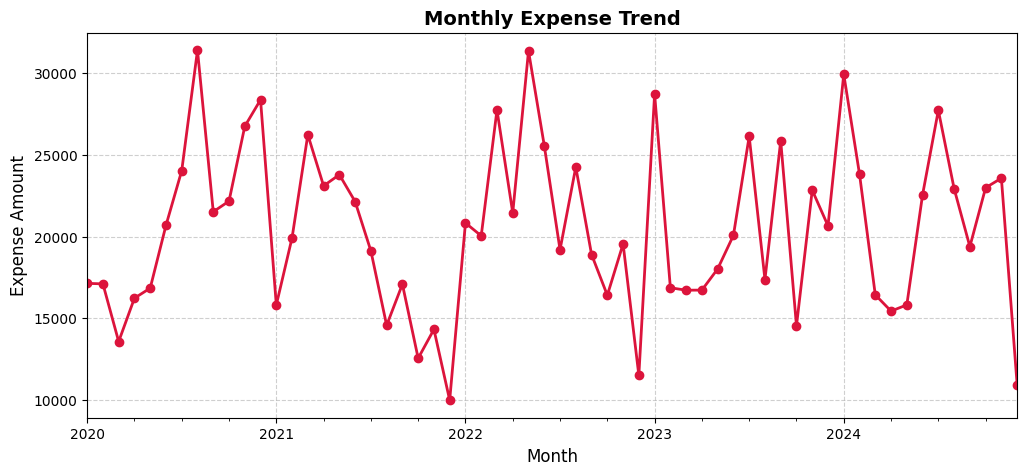

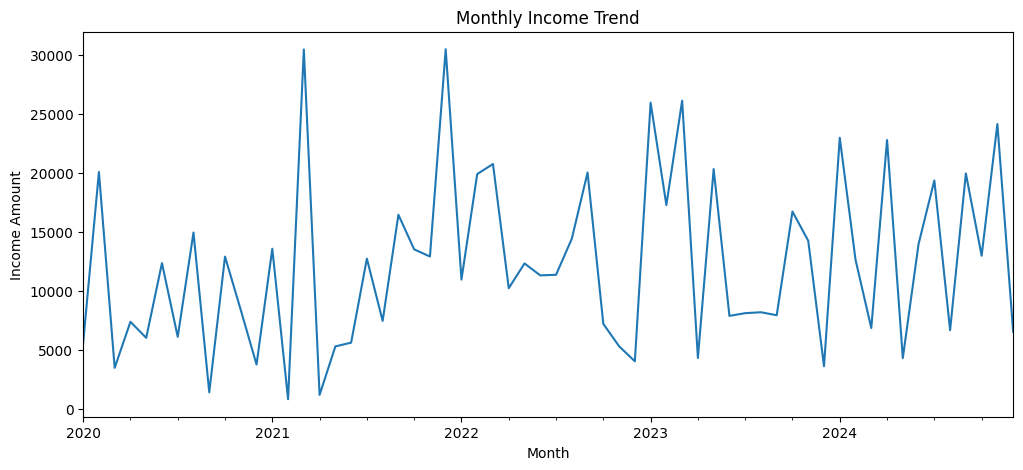

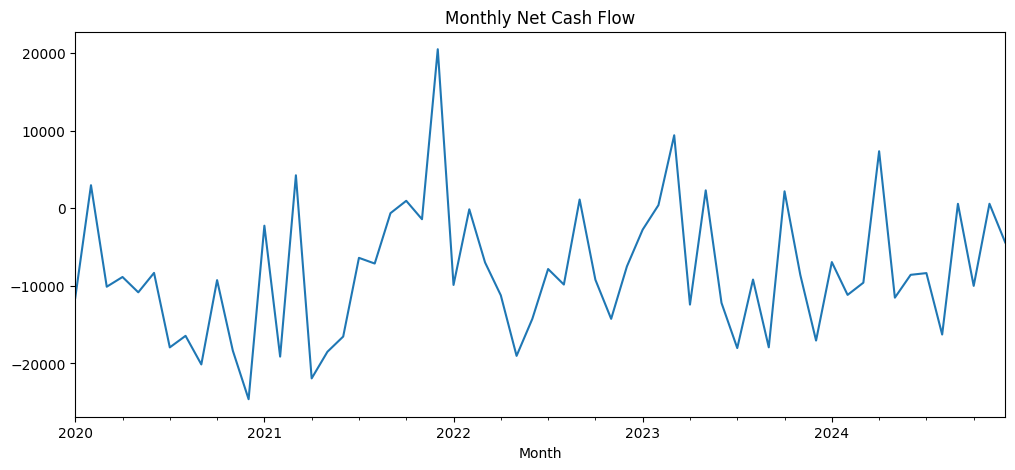

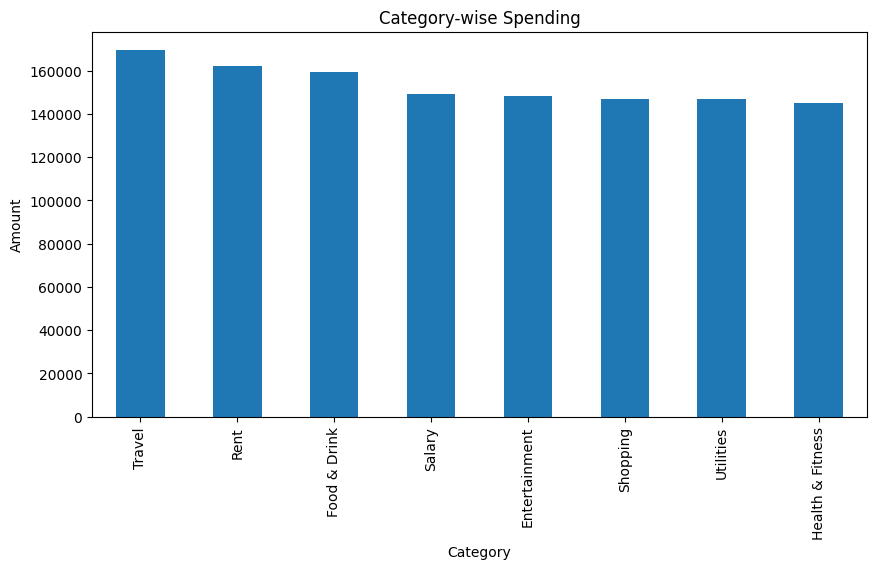

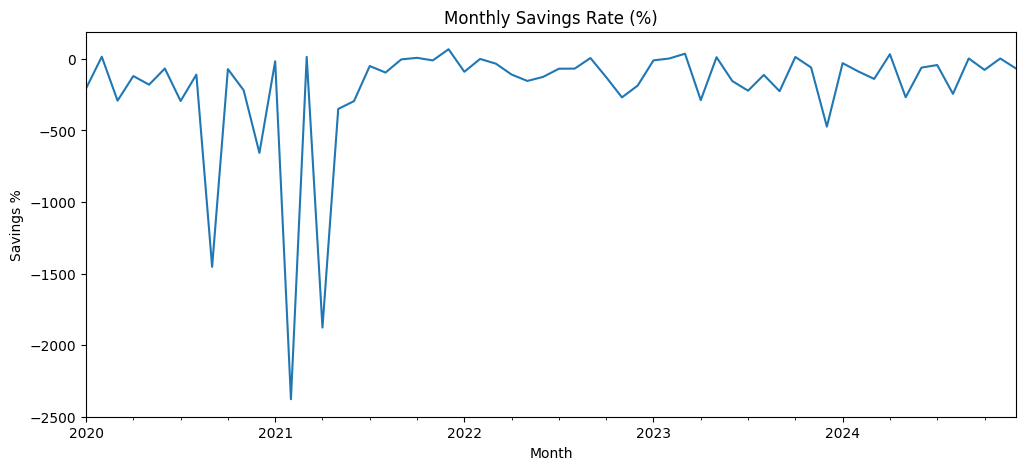

Expense Volatility: 5120.184818004802
Series([], Name: count, dtype: int64)


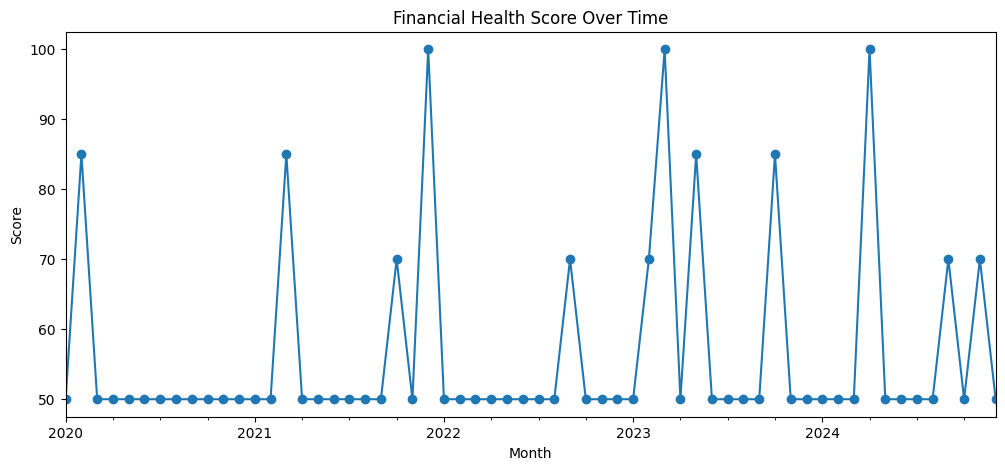

Number of anomalies: 37


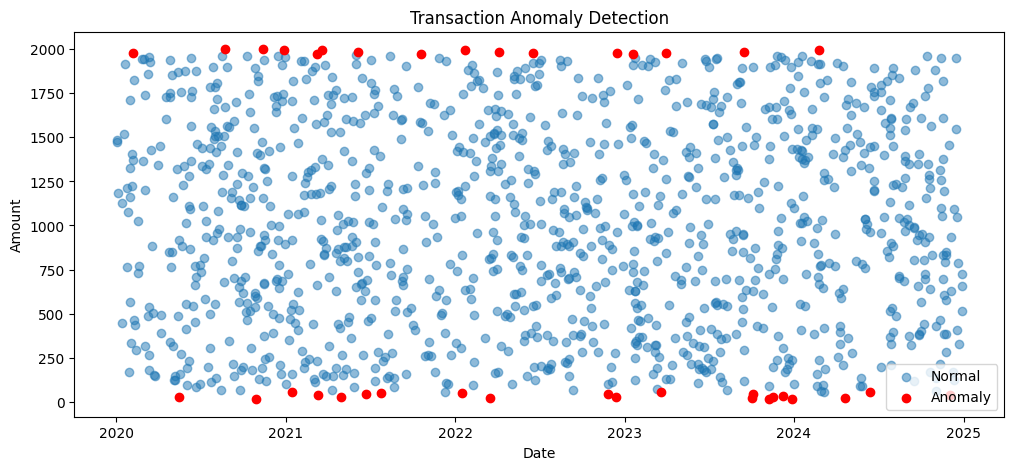

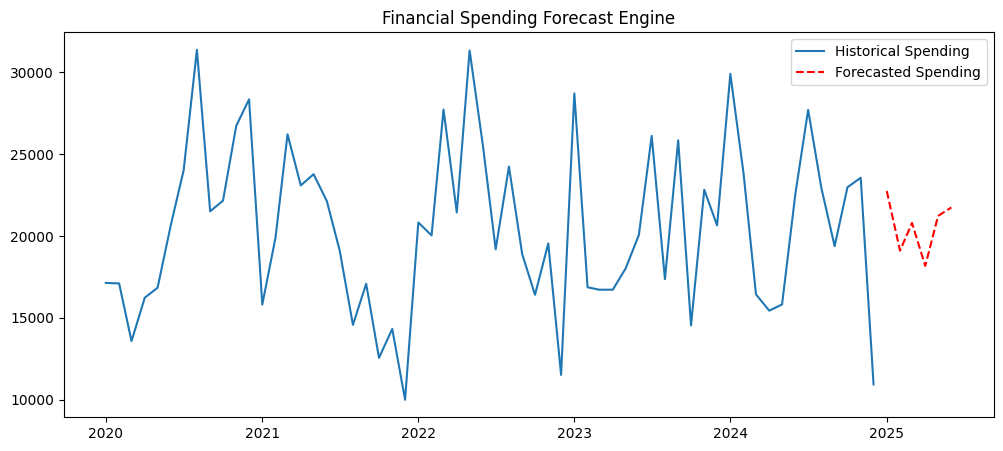

AttributeError: 'function' object has no attribute 'columns'

In [ ]:
from turtle import st

import pandas as pd
import matplotlib.pyplot as plt

# 1. First, tell Python what 'df' is by loading the data
df = pd.read_csv(r"D:\finance-intelligence-system\data\raw\Personal_Finance_Dataset.csv")

# 2. Run your basic inspections
print("--- Data Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Summary Statistics ---")
print(df.describe())

# 3. Process the dates and group the data
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

income_df = df[df['Type'] == 'Income']
expense_df = df[df['Type'] == 'Expense']

monthly_expense = expense_df.groupby('Month')['Amount'].sum()

# 4. Generate your trend chart
plt.figure(figsize=(12, 5))
monthly_expense.plot(marker='o', color='crimson', linewidth=2)
plt.title("Monthly Expense Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Expense Amount", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
monthly_income = income_df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(12,5))

monthly_income.plot()

plt.title("Monthly Income Trend")
plt.xlabel("Month")
plt.ylabel("Income Amount")

plt.show()
cashflow = pd.DataFrame({
    'Income': monthly_income,
    'Expense': monthly_expense
})

cashflow['Net Cash Flow'] = cashflow['Income'] - cashflow['Expense']

cashflow
cashflow['Net Cash Flow'].plot(figsize=(12,5))

plt.title("Monthly Net Cash Flow")

plt.show()
category_spending = expense_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

category_spending
category_spending.plot(kind='bar', figsize=(10,5))

plt.title("Category-wise Spending")

plt.ylabel("Amount")

plt.show()
category_spending.head(5)
cashflow['Savings'] = cashflow['Income'] - cashflow['Expense']
cashflow.head()
cashflow['Savings Rate'] = (
    cashflow['Savings'] / cashflow['Income']
) * 100
plt.figure(figsize=(12,5))

cashflow['Savings Rate'].plot()

plt.title("Monthly Savings Rate (%)")

plt.ylabel("Savings %")

plt.show()
expense_volatility = monthly_expense.std()

print("Expense Volatility:", expense_volatility)
recurring = df['Transaction Description'].value_counts()

recurring.head(10)
recurring_expenses = recurring[recurring > 3]

print(recurring_expenses)
def financial_health_score(row):
    
    score = 50
    
    # Savings contribution
    if row['Savings Rate'] > 20:
        score += 30
    elif row['Savings Rate'] > 10:
        score += 15
    
    # Positive cash flow
    if row['Net Cash Flow'] > 0:
        score += 20
    
    return min(score, 100)
cashflow['Health Score'] = cashflow.apply(
    financial_health_score,
    axis=1
)
cashflow[['Savings Rate','Net Cash Flow','Health Score']]
plt.figure(figsize=(12,5))

cashflow['Health Score'].plot(marker='o')

plt.title("Financial Health Score Over Time")

plt.ylabel("Score")

plt.show()




#05_anomaly_detection.ipynb

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Personal_Finance_Dataset.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()
expense_df = df[df['Type'] == 'Expense'].copy()

try:
    from sklearn.ensemble import IsolationForest
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.ensemble import IsolationForest
model = IsolationForest(
    contamination=0.03,
    random_state=42
)
expense_df['anomaly'] = model.fit_predict(
    expense_df[['Amount']]
)
anomalies = expense_df[expense_df['anomaly'] == -1]

anomalies.head()

print("Number of anomalies:", len(anomalies))

normal = expense_df[expense_df['anomaly'] == 1]
plt.figure(figsize=(12,5))

plt.scatter(
    normal['Date'],
    normal['Amount'],
    label='Normal',
    alpha=0.5
)

plt.scatter(
    anomalies['Date'],
    anomalies['Amount'],
    color='red',
    label='Anomaly'
)

plt.title("Transaction Anomaly Detection")

plt.xlabel("Date")
plt.ylabel("Amount")

plt.legend()

plt.show()
anomalies.sort_values(
    by='Amount',
    ascending=False
).head(10)



expense_df = df[df['Type'] == 'Expense'].copy()
expense_df = df[df['Type'] == 'Expense'].copy()
expense_df['Month'] = expense_df['Date'].dt.to_period('M')
monthly_expense = expense_df.groupby('Month', as_index=False)['Amount'].sum()
monthly_expense['Month'] = monthly_expense['Month'].astype(str)

monthly_expense['Month'] = pd.to_datetime(monthly_expense['Month'])
forecast_df = monthly_expense.rename(
    columns={
        'Month': 'ds',
        'Amount': 'y'
    }
)
forecast_df.head()
# 1. Install Statsmodels in your terminal
# pip install statsmodels

# 2. Inside your notebook, replace Prophet with Exponential Smoothing
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
import streamlit as st
import streamlit as st

# Prepare your monthly data (make sure 'Month' is a datetime index)
df_forecast = monthly_expense.set_index('Month').asfreq('MS')

# Train the model
model = ExponentialSmoothing(df_forecast['Amount'], trend='add', seasonal='add', seasonal_periods=12)
fitted_model = model.fit()

# Forecast next 6 months
forecast = fitted_model.forecast(steps=6)

# Plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_forecast.index, df_forecast['Amount'], label='Historical Spending')
plt.plot(forecast.index, forecast.values, label='Forecasted Spending', color='red', linestyle='--')
plt.title("Financial Spending Forecast Engine")
plt.legend()
plt.show()


df.head()
# KPI Metrics

total_income = df[df['Type'] == 'Income']['Amount'].sum()

total_expense = df[df['Type'] == 'Expense']['Amount'].sum()

net_savings = total_income - total_expense

# ensure 'st' is the Streamlit module (fix accidental 'from turtle import st' import)
try:
    if not hasattr(st, "columns"):
except NameError:

col1, col2, col3 = st.columns(3)

col1.metric(" Total Income", f"${total_income:,.2f}")

col2.metric("💸 Total Expense", f"${total_expense:,.2f}")

col3.metric("💰 Net Savings", f"${net_savings:,.2f}")

st.sidebar.header("Filters")

categories = st.sidebar.multiselect(
    "Select Categories",
    options=df['Category'].unique(),
    default=df['Category'].unique()
)

filtered_df = df[df['Category'].isin(categories)]

expense_df = filtered_df[filtered_df['Type'] == 'Expense']

category_spending = expense_df.groupby('Category')['Amount'].sum()

st.subheader("📊 Category-wise Spending")

fig, ax = plt.subplots(figsize=(10,5))

category_spending.plot(kind='bar', ax=ax)

plt.xticks(rotation=45)

st.pyplot(fig)
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])

filtered_df['Month'] = filtered_df['Date'].dt.to_period('M').astype(str)
monthly_expense = (
    filtered_df[filtered_df['Type']=='Expense']
    .groupby('Month')['Amount']
    .sum()
)
st.subheader("📈 Monthly Expense Trend")

fig2, ax2 = plt.subplots(figsize=(12,5))

monthly_expense.plot(ax=ax2)

plt.xticks(rotation=45)

st.pyplot(fig2)

In [3]:
df.shape


(1500, 5)

In [14]:
# The exclamation mark tells Jupyter to run this in the terminal background
!pip install matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for your financial charts
sns.set_theme(style="whitegrid")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Added 'r' before the string to handle Windows backslashes, and fixed the extension to .csv
df = pd.read_csv(r"D:\finance-intelligence-system\data\raw\Personal_Finance_Dataset.csv")

df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [1]:
import pandas as pd

In [6]:
pip install pandas

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl (12.5 MB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
